In [25]:
import pandas as pd
import os
import numpy as np
os.chdir(r"C:\Users\gotta\OneDrive\Documents\Bureau\X\4A\US\Stanford\Classes\CS 230\Project\CS-230-Deep-Learning-Project\data")


In [26]:
# Define the path to the file
file_path = r"CAISO_LMP_Forecasts\CAISO_LMP_Forecast_2022_07\20220701_20220731_PRC_LMP_DAM_20251012_16_54_24_v12.csv"
# Read the file using pandas
forecast_data = pd.read_csv(file_path)
columns_to_drop = ['OPR_INTERVAL', 'INTERVALSTARTTIME_GMT', 'INTERVALENDTIME_GMT','NODE_ID_XML','PNODE_RESMRID','GRP_TYPE','NODE',
                    'MARKET_RUN_ID','XML_DATA_ITEM','POS','GROUP']
# Drop the columns
df = forecast_data.drop(columns=columns_to_drop)
df = df.sort_values(by=['OPR_DT', 'OPR_HR'], ascending=[True, True]).reset_index(drop=True)
df

,OPR_DT,OPR_HR,NODE_ID,LMP_TYPE,MW
0,2022-07-01,1,TH_NP15_GEN-APND,LMP,73.70168
1,2022-07-01,1,TH_NP15_GEN-APND,MCC,2.95362
2,2022-07-01,1,TH_NP15_GEN-APND,MCE,70.70564
3,2022-07-01,1,TH_NP15_GEN-APND,MCL,0.04242
4,2022-07-01,1,TH_NP15_GEN-APND,MGHG,0.00000
...,...,...,...,...,...
10795,2022-07-30,24,TH_ZP26_GEN-APND,LMP,91.13678
10796,2022-07-30,24,TH_ZP26_GEN-APND,MCC,0.00000
10797,2022-07-30,24,TH_ZP26_GEN-APND,MCE,96.43083
10798,2022-07-30,24,TH_ZP26_GEN-APND,MCL,-5.29405


In [27]:
# Filter out rows where LMP_TYPE is 'MGHG'
df = df[df['LMP_TYPE'] != 'MGHG']

# Pivot the table to create separate columns for each LMP_TYPE
df = df.pivot(index=['OPR_DT', 'OPR_HR', 'NODE_ID'], columns='LMP_TYPE', values='MW')

# Reset the index to flatten the DataFrame
df = df.reset_index()

# Rename the columns for clarity
df = df.rename(columns={'LMP': 'LMP', 'MCC': 'MCC', 'MCE': 'MCE', 'MCL': 'MCL'})

# Display the resulting DataFrame
df

LMP_TYPE,OPR_DT,OPR_HR,NODE_ID,LMP,MCC,MCE,MCL
0,2022-07-01,1,TH_NP15_GEN-APND,73.70168,2.95362,70.70564,0.04242
1,2022-07-01,1,TH_SP15_GEN-APND,61.42091,-5.72823,70.70564,-3.55649
2,2022-07-01,1,TH_ZP26_GEN-APND,65.16609,-2.23759,70.70564,-3.30195
3,2022-07-01,2,TH_NP15_GEN-APND,67.25023,1.79759,65.39378,0.05885
4,2022-07-01,2,TH_SP15_GEN-APND,59.82000,-2.55258,65.39378,-3.02119
...,...,...,...,...,...,...,...
2155,2022-07-30,23,TH_SP15_GEN-APND,99.51273,0.00000,101.58506,-2.07234
2156,2022-07-30,23,TH_ZP26_GEN-APND,95.57123,0.00000,101.58506,-6.01384
2157,2022-07-30,24,TH_NP15_GEN-APND,87.72000,-3.68679,96.43083,-5.02405
2158,2022-07-30,24,TH_SP15_GEN-APND,94.45400,0.00000,96.43083,-1.97683


In [34]:
# For each row of the DataFrame, verify that MCC represents less than 10%of LMP value
df['MCC_%']= np.abs(df['MCC']) / df['LMP'] * 100
#print rows where MCC_% is greater than 10%
print(df[df['MCC_%'] > 30])

LMP_TYPE      OPR_DT  OPR_HR           NODE_ID       LMP       MCC        MCE  \
104       2022-07-02      11  TH_ZP26_GEN-APND  17.54696  -7.15649   26.48312   
106       2022-07-02      12  TH_SP15_GEN-APND  19.84760  -8.09123   28.96417   
107       2022-07-02      12  TH_ZP26_GEN-APND  16.85000 -10.05192   28.96417   
109       2022-07-02      13  TH_SP15_GEN-APND  23.03516  -7.32786   31.46427   
110       2022-07-02      13  TH_ZP26_GEN-APND  19.47252  -9.63822   31.46427   
...              ...     ...               ...       ...       ...        ...   
992       2022-07-14      19  TH_ZP26_GEN-APND  70.00000 -45.70317  115.70317   
1064      2022-07-15      19  TH_ZP26_GEN-APND  93.37219 -33.22664  126.59883   
1517      2022-07-22       2  TH_ZP26_GEN-APND  53.38000 -17.70519   75.34201   
1658      2022-07-24       1  TH_ZP26_GEN-APND  52.00000 -26.43356   83.04241   
1727      2022-07-24      24  TH_ZP26_GEN-APND  52.00000 -26.18433   82.53387   

LMP_TYPE      MCL      MCC_

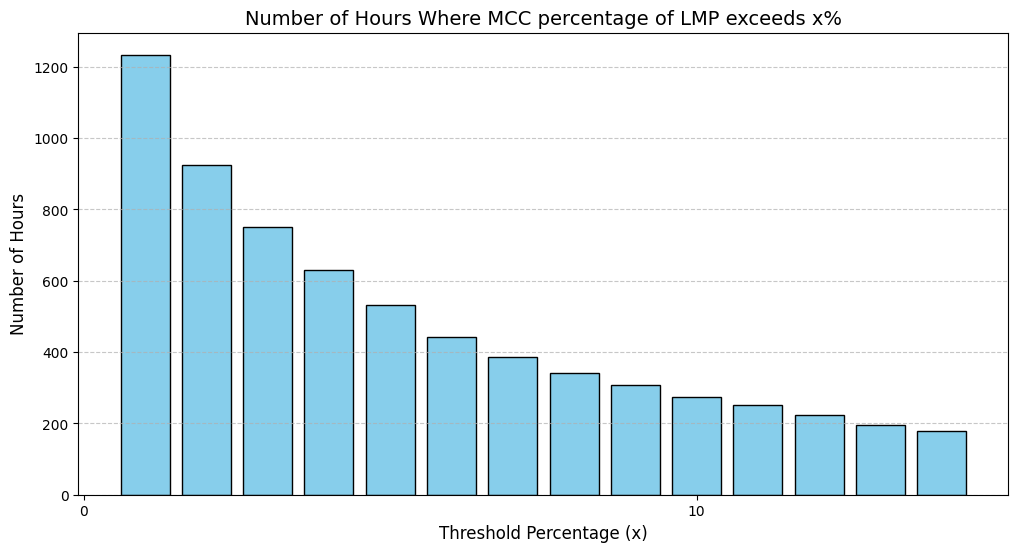

In [38]:
import matplotlib.pyplot as plt

# Define the range of x values (percentages)
x_values = range(1, 15)

# Calculate the number of hours where MCC_% is greater than each x
hours_greater_than_x = [len(df[df['MCC_%'] > x]) for x in x_values]

# Create the bar plot
plt.figure(figsize=(12, 6))
plt.bar(x_values, hours_greater_than_x, color='skyblue', edgecolor='black')
plt.xlabel('Threshold Percentage (x)', fontsize=12)
plt.ylabel('Number of Hours', fontsize=12)
plt.title('Number of Hours Where MCC percentage of LMP exceeds x%', fontsize=14)
plt.xticks(range(0, 15, 10))  # Set x-axis ticks every 10%
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()